<a href="https://colab.research.google.com/github/MamoMGD1/ISE302-DataMining-GroupProject/blob/main/shared/01_core_numeric.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Core Numeric & Date Columns (Team 1)

## Goal of this notebook
This notebook processes **11 core numeric columns**. Based on peer feedback regarding data manipulation and artificial skewness, we have implemented an advanced imputation strategy to preserve the natural variance of the dataset.

### Our Advanced Methodology:
1. **Iterative Imputation:** Instead of simple Median filling (which creates artificial spikes), we use a multivariate imputer. This models each feature with missing values as a function of others, providing a more realistic and data-faithful estimation.
2. **Production Lifecycle Preservation:** For `Üretim Yılı (İlk/Son)`, we now calculate the **midpoint (mean)** of the range (e.g., "2014 - 2018" becomes 2016). This preserves generational data that would otherwise be lost by only taking the start year.
3. **Temporal Transformation:** Converting `İlan Tarihi` into "days elapsed" since the earliest listing to allow the model to learn time-based price trends.
4. **Turkish Decimal Standardization:** Converting Turkish decimal separators (`,`) to dots (`.`) to ensure high-precision numeric conversion.

## Columns Handled
`Fiyat`, `Yıl`, `Kilometre`, `İlan Tarihi`, `Ortalama Kasko`, `Ortalama Trafik Sigortası`, `Üretim Yılı (İlk/Son)`, `Silindir Sayısı`, `Koltuk Sayısı`, `Bagaj Hacmi`, `Yakıt Deposu`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

sns.set_theme(style="whitegrid")

# Load raw dataset
RAW_URL = "https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/raw_dataset.csv"
df_full = pd.read_csv(RAW_URL)

# Isolate Team 1 columns
MY_COLUMNS = [
    'Fiyat', 'Yıl', 'Kilometre', 'İlan Tarihi',
    'Ortalama Kasko', 'Ortalama Trafik Sigortası',
    'Üretim Yılı (İlk/Son)', 'Silindir Sayısı',
    'Koltuk Sayısı', 'Bagaj Hacmi', 'Yakıt Deposu'
]
df = df_full[MY_COLUMNS].copy()

print(f"✅ Subset Loaded. Shape: {df.shape}")
df.head(3)

✅ Subset Loaded. Shape: (3424, 11)


,Fiyat,Yıl,Kilometre,İlan Tarihi,Ortalama Kasko,Ortalama Trafik Sigortası,Üretim Yılı (İlk/Son),Silindir Sayısı,Koltuk Sayısı,Bagaj Hacmi,Yakıt Deposu
0,2.425.000TL,2025,6.001 km,26 Şubat 2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.900.000TL,2025,16.000 km,26 Şubat 2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.150.000TL,2015,265.000 km,26 Şubat 2026,18.918TL,11.055TL,2014 - 2017,4.0,5.0,401 lt,55 lt


## Step 1 — Pre-Cleaning Exploratory Analysis
We visualize the missing value density. Several columns show missing rates above 30%. Simply filling these with a single median value would result in "data manipulation" spikes. Our goal is to prepare these columns for multivariate imputation.

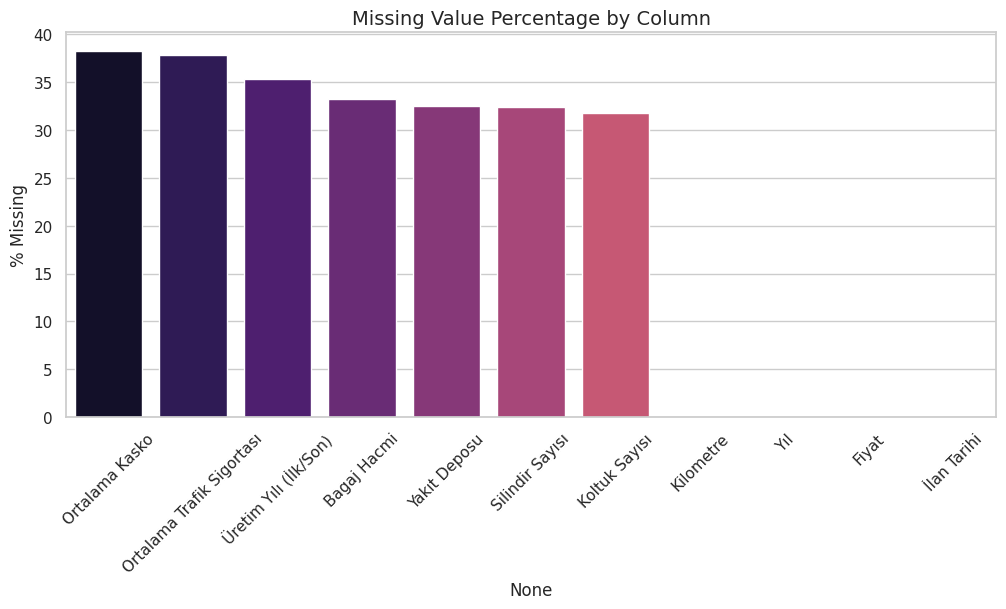

In [2]:
# Calculate null percentages
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

# Visualize with fix for Seaborn FutureWarning
plt.figure(figsize=(12, 5))
sns.barplot(x=null_pct.index, y=null_pct.values, hue=null_pct.index, palette='magma', legend=False)
plt.title('Missing Value Percentage by Column', fontsize=14)
plt.ylabel('% Missing', fontsize=12)
plt.xticks(rotation=45)
plt.show()

## Step 2 — Data Cleaning & Advanced Imputation
**What we are doing:**
* **Midpoint Extraction:** We average the start and end years of the production range.
* **Unit Stripping:** Removing "TL", "km", and "lt".
* **Turkish Formatting Fix:** Standardizing decimal commas to dots.
* **Iterative Imputation:** Filling all NaNs by analyzing correlations between columns (e.g., Price vs. Age vs. Engine size).

In [3]:
# 1. Standardize Price (Fiyat) - Removing currency and formatting
df['Fiyat'] = df['Fiyat'].astype(str).str.replace('TL', '', regex=False).str.replace('.', '', regex=False).str.strip().astype(int)

# 2. Üretim Yılı Logic: Midpoint of the Range
# Instead of taking just the first year, we average the start and end years to preserve generation data
def get_year_midpoint(year_str):
    years = pd.Series(str(year_str)).str.extractall(r'(\d{4})')[0].astype(float)
    if not years.empty:
        return years.mean()
    return np.nan

df['Üretim Yılı (İlk/Son)'] = df['Üretim Yılı (İlk/Son)'].apply(get_year_midpoint)

# 3. Strip units and handle decimals for numeric columns
# We leave them as NaN here so the Iterative Imputer can "predict" them later
for col in ['Kilometre', 'Ortalama Kasko', 'Ortalama Trafik Sigortası']:
    df[col] = (df[col].astype(str)
               .str.replace(' km', '', regex=False)
               .str.replace('TL', '', regex=False)
               .str.replace('.', '', regex=False)
               .str.strip()
               .replace('nan', np.nan))
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['Bagaj Hacmi', 'Yakıt Deposu']:
    df[col] = (df[col].astype(str)
               .str.replace(' lt', '', regex=False)
               .str.replace(',', '.', regex=False) # Turkish decimal comma fix
               .str.strip()
               .replace('nan', np.nan))
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Clean Date (İlan Tarihi) - Conversion to linear time
df['İlan Tarihi'] = pd.to_datetime(df['İlan Tarihi'], dayfirst=True, errors='coerce', format='mixed')
min_date = df['İlan Tarihi'].min()
df['İlan Tarihi'] = (df['İlan Tarihi'] - min_date).dt.days

# 5. Multivariate Iterative Imputation
# Estimates missing values based on correlations between all numeric features
imputer = IterativeImputer(random_state=42, max_iter=10)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# 6. Precision Rounding & Casting
# Convert business-critical values to integers for a cleaner dataset
df_imputed['Fiyat'] = df_imputed['Fiyat'].round().astype(int)
df_imputed['Kilometre'] = df_imputed['Kilometre'].round().astype(int)

# Round discrete car specs to nearest whole number
for col in ['Yıl', 'Silindir Sayısı', 'Koltuk Sayısı', 'İlan Tarihi']:
    df_imputed[col] = df_imputed[col].round().astype(int)

# Round technical estimations to 2 decimal places to maintain imputer signal
float_cols = ['Ortalama Kasko', 'Ortalama Trafik Sigortası', 'Üretim Yılı (İlk/Son)', 'Bagaj Hacmi', 'Yakıt Deposu']
df_imputed[float_cols] = df_imputed[float_cols].round(2)

df = df_imputed
print("✅ Advanced Imputation and Precision Rounding Completed.")

✅ Advanced Imputation and Cleaning Completed.


## Step 3 — Post-Cleaning Distribution Analysis

We visualize the histograms of key features to evaluate data integrity and evaluate our processing results.

**What we are observing:**
* **Skewness Check:** Features like `Kilometre` and `Fiyat` show a heavy right-skew due to luxury and high-mileage outliers.
* **Natural Variance:** By using **Iterative Imputation** instead of simple median filling, we have avoided artificial "vertical spikes" and preserved the statistical distribution of the data.
* **Predictive Signal:** The multivariate approach ensures that missing values are estimated based on correlations (e.g., Price vs. Year), creating a more realistic dataset.
* **Consistency:** We applied **Precision Rounding** to ensure business-logic consistency (e.g., integers for price and mileage) for the upcoming modeling phase.

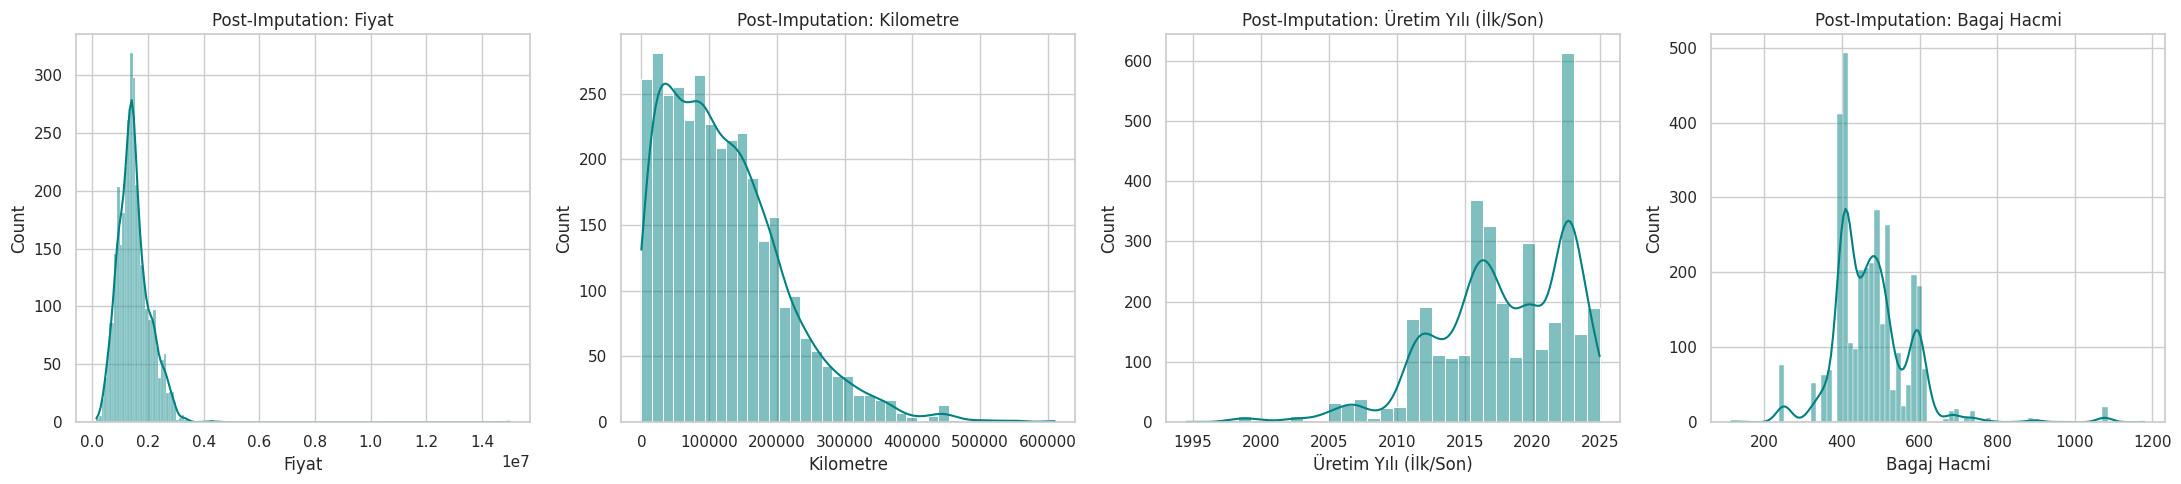

In [4]:
cols_to_plot = ['Fiyat', 'Kilometre', 'Üretim Yılı (İlk/Son)', 'Bagaj Hacmi']
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for i, col in enumerate(cols_to_plot):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Post-Imputation: {col}')

plt.tight_layout()
plt.show()

## Step 4 — Integrity Verification
Final check to ensure the output dataframe is 100% numeric and complete before merging with other team files.

In [5]:
df_team1 = df.copy()

# Ensure integrity
assert df_team1.isnull().sum().sum() == 0, "❌ Error: Missing values remain!"
assert df_team1.select_dtypes(exclude='number').shape[1] == 0, "❌ Error: Non-numeric data found!"

print(f"✅ Team 1 Final Output Ready. Shape: {df_team1.shape}")
display(df_team1.info())
display(df_team1.head())

✅ Team 1 Final Output Ready. Shape: (3424, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3424 entries, 0 to 3423
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Fiyat                      3424 non-null   float64
 1   Yıl                        3424 non-null   int64  
 2   Kilometre                  3424 non-null   float64
 3   İlan Tarihi                3424 non-null   int64  
 4   Ortalama Kasko             3424 non-null   float64
 5   Ortalama Trafik Sigortası  3424 non-null   float64
 6   Üretim Yılı (İlk/Son)      3424 non-null   float64
 7   Silindir Sayısı            3424 non-null   int64  
 8   Koltuk Sayısı              3424 non-null   int64  
 9   Bagaj Hacmi                3424 non-null   float64
 10  Yakıt Deposu               3424 non-null   float64
dtypes: float64(7), int64(4)
memory usage: 294.4 KB


None

,Fiyat,Yıl,Kilometre,İlan Tarihi,Ortalama Kasko,Ortalama Trafik Sigortası,Üretim Yılı (İlk/Son),Silindir Sayısı,Koltuk Sayısı,Bagaj Hacmi,Yakıt Deposu
0,2425000.0,2025,6001.0,1,16823.59234,12532.514699,2024.524726,3,5,520.096432,49.847891
1,2900000.0,2025,16000.0,1,18054.32961,12413.265172,2024.561718,4,5,550.278944,51.937234
2,1150000.0,2015,265000.0,0,18918.00000,11055.000000,2015.500000,4,5,401.000000,55.000000
3,1240000.0,2014,196000.0,0,17977.00000,11055.000000,2015.500000,4,5,401.000000,55.000000
4,690000.0,2011,305000.0,0,16252.40050,11395.225689,2011.476979,4,5,451.831149,61.573717
